# **Спринт IV: разработка личного виртуального коуча**

Задача спринта IV разбивается на пять этапов:
1. Выбрать сферу применения виртуального коуча (йога, футбол и т. д. — креативные идеи приветствуются).
2. Выбрать небольшой ролик в качестве референса и повторить движения из него.
3. Снять выполнение этих движений на видео.
4. Загрузить и предобработать своё видео.
5. Сравнить своё видео с референсом и вычислить косинусное и взвешенное расстояния.


По условиям задачи: *"Этот виртуальный коуч предоставляет спортсменам фрагмент одного или нескольких видео, после чего спортсмены повторяют движения коуча на видео и получают оценку схожести их движений с референсными. Можно выводить оценку на экран с помощью print() или же отрисовывать её вместе с каркасом спортсмена непосредственно в видео."*


# Virtual Coach AI
## Финальный пайплайн  Sprint IV

Система компьютерного зрения для оценки качества выполнения физических упражнений

### Этапы обработки

Входное видео  
↓  
Извлечение кадров  
↓  
Определение позы с помощью Keypoint R-CNN  
↓  
Нормализация позы  
↓  
Автоматический поиск соответствующего фрагмента  
↓  
Выравнивание поз  
↓  
Синхронизация последовательностей с помощью DTW (Dynamic Time Warping)  
↓  
Расчёт метрик сходства  
↓  
Формирование отчёта с обратной связью

In [1]:
# GitHub Project Preparation
# Virtual Coach AI
# Sprint IV Final Notebook Structure


structure = r"""

Sprint_4_Virtual_Coach_Final.ipynb

│
├── Part I — Project Setup
│   │
│   ├── Environment Setup
│   ├── Imports
│   ├── Project Configuration
│   ├── Project Structure
│   └── Load Videos
│
├── Part II — Pose Analysis Pipeline
│   │
│   ├── Frame Extraction
│   ├── Resize Frames
│   ├── Keypoint R-CNN Pose Estimation
│   ├── Pose Normalization
│   ├── Automatic Segment Search
│   ├── DTW Synchronization
│   ├── Similarity Metrics
│   └── Save CSV Results
│
├── Part III — Results and Visualization
│   │
│   ├── Comparison Video
│   ├── Score Curve
│   ├── Performance Metrics
│   ├── Automatic Feedback
│   ├── Final Report
│   └── Final Conclusion
│
└── Project Documentation
    │
    ├── GitHub Repository Preparation
    ├── requirements.txt
    ├── scripts/main.py
    ├── images/
    │   ├── architecture.png
    │   ├── pipeline.png
    │   ├── score_curve.png
    │   └── demo_frame.png
    ├── README.md
    └── Final Project Structure

"""

print("=" * 70)
print("Virtual Coach AI")
print("Sprint IV - Final Notebook Structure")
print("=" * 70)

print(structure)

print("=" * 70)
print("Notebook sections: 4")
print("Project status: Final Version")
print("Ready for GitHub publication")
print("=" * 70)

Virtual Coach AI
Sprint IV - Final Notebook Structure


Sprint_4_Virtual_Coach_Final.ipynb

│
├── Part I — Project Setup
│   │
│   ├── Environment Setup
│   ├── Imports
│   ├── Project Configuration
│   ├── Project Structure
│   └── Load Videos
│
├── Part II — Pose Analysis Pipeline
│   │
│   ├── Frame Extraction
│   ├── Resize Frames
│   ├── Keypoint R-CNN Pose Estimation
│   ├── Pose Normalization
│   ├── Automatic Segment Search
│   ├── DTW Synchronization
│   ├── Similarity Metrics
│   └── Save CSV Results
│
├── Part III — Results and Visualization
│   │
│   ├── Comparison Video
│   ├── Score Curve
│   ├── Performance Metrics
│   ├── Automatic Feedback
│   ├── Final Report
│   └── Final Conclusion
│
└── Project Documentation
    │
    ├── GitHub Repository Preparation
    ├── requirements.txt
    ├── scripts/main.py
    ├── images/
    │   ├── architecture.png
    │   ├── pipeline.png
    │   ├── score_curve.png
    │   └── demo_frame.png
    ├── README.md
    └── Final Project Str

In [2]:
# Install tree utility

!apt-get install tree -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (84.5 kB/s)
Selecting previously unselected package tree.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
# Show Virtual Coach project structure

#PROJECT_DIR = "/content/drive/MyDrive/Virtual_Coach"

#!tree -L 3 "{PROJECT_DIR}"

### Часть 1
Setup + Project Configuration + Imports

In [3]:
# Install dependencies
!pip install opencv-python pandas matplotlib tqdm dtaidistance scipy fastdtw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 39.0 MB/s eta 0:00:00
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567858 sha256=042b99357f5c7beb6b5eeef8df8b901a09952de59b84e5287a36e5cbb6642329
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw


In [4]:
# Import libraries
import os
import sys

import cv2
import torch
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


from tqdm import tqdm

In [5]:
# Connect Google Drive
from google.colab import drive


drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Virtual Coach AI
# Project Configuration

import os
import sys


PROJECT_DIR = "/content/drive/MyDrive/Virtual_Coach"


# Проверка проекта

assert os.path.exists(PROJECT_DIR), \
"Virtual_Coach folder not found"


print("Project:")
print(PROJECT_DIR)



# Добавляем проект в Python PATH

if PROJECT_DIR not in sys.path:

    sys.path.insert(
        0,
        PROJECT_DIR
    )



# Основные директории

SRC_DIR = os.path.join(
    PROJECT_DIR,
    "src"
)


DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)


RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)


VIDEO_DIR = os.path.join(
    RESULTS_DIR,
    "video"
)


CSV_DIR = os.path.join(
    RESULTS_DIR,
    "csv"
)


PLOTS_DIR = os.path.join(
    RESULTS_DIR,
    "plots"
)



# Создание результатов

for folder in [
    VIDEO_DIR,
    CSV_DIR,
    PLOTS_DIR
]:

    os.makedirs(
        folder,
        exist_ok=True
    )



print("\nFolders ready")

print(
    "src:",
    SRC_DIR
)

Project:
/content/drive/MyDrive/Virtual_Coach

Folders ready
src: /content/drive/MyDrive/Virtual_Coach/src


In [8]:
# Проверка файлов src

import os

print(
    "SRC CONTENT:"
)

for file in os.listdir(SRC_DIR):

    print("-", file)

SRC CONTENT:
- virtual_coach


In [9]:
# Проверка структуры проекта

for root, dirs, files in os.walk(PROJECT_DIR):

    level = root.replace(
        PROJECT_DIR,
        ""
    ).count(os.sep)

    if level <= 2:

        print(root)

/content/drive/MyDrive/Virtual_Coach
/content/drive/MyDrive/Virtual_Coach/results
/content/drive/MyDrive/Virtual_Coach/results/video
/content/drive/MyDrive/Virtual_Coach/results/csv
/content/drive/MyDrive/Virtual_Coach/results/plots
/content/drive/MyDrive/Virtual_Coach/results/videos
/content/drive/MyDrive/Virtual_Coach/results/reports
/content/drive/MyDrive/Virtual_Coach/src
/content/drive/MyDrive/Virtual_Coach/src/virtual_coach
/content/drive/MyDrive/Virtual_Coach/data
/content/drive/MyDrive/Virtual_Coach/data/videos
/content/drive/MyDrive/Virtual_Coach/scripts
/content/drive/MyDrive/Virtual_Coach/images
/content/drive/MyDrive/Virtual_Coach/notebooks
/content/drive/MyDrive/Virtual_Coach/examples
/content/drive/MyDrive/Virtual_Coach/docs
/content/drive/MyDrive/Virtual_Coach/.git
/content/drive/MyDrive/Virtual_Coach/.git/hooks
/content/drive/MyDrive/Virtual_Coach/.git/info
/content/drive/MyDrive/Virtual_Coach/.git/branches
/content/drive/MyDrive/Virtual_Coach/.git/refs
/content/drive/M

In [10]:
# Проверяем Python пакет
# если нет __init__.py, создать:

init_file = os.path.join(
    SRC_DIR,
    "__init__.py"
)


if not os.path.exists(init_file):

    open(
        init_file,
        "w"
    ).close()


print(
    "init.py ready"
)

init.py ready


In [11]:
# pose_utils.py
%%writefile /content/drive/MyDrive/Virtual_Coach/src/pose_utils.py

import numpy as np
import cv2


COCO_WEIGHTS = np.array([
    0.5,0.3,0.3,0.3,0.3,
    1,1,
    1.5,1.5,
    1.8,1.8,
    2,2,
    2.5,2.5,
    3,3
])


def normalize_pose(kp):

    if kp is None:
        return None

    kp = kp.copy()


    # hip center

    center = (
        kp[11,:2] +
        kp[12,:2]
    ) / 2


    kp[:,:2] -= center


    # shoulder scale

    scale = np.linalg.norm(
        kp[5,:2] -
        kp[6,:2]
    )


    if scale == 0:
        return None


    kp[:,:2] /= scale


    return kp



def affine_transform(source, target):

    points = [
        5,6,
        11,12,
        13,14,
        15,16
    ]


    src = source[points,:2].astype(
        np.float32
    )

    dst = target[points,:2].astype(
        np.float32
    )


    matrix,_ = cv2.estimateAffinePartial2D(
        src,
        dst
    )


    if matrix is None:
        return None


    aligned = cv2.transform(
        np.array([source[:,:2]]),
        matrix
    )[0]


    return aligned



def cosine_similarity(a,b):

    a = a.flatten()
    b = b.flatten()


    denominator = (
        np.linalg.norm(a) *
        np.linalg.norm(b)
    )


    if denominator == 0:
        return 0


    return np.dot(a,b) / denominator



def weighted_distance(a,b):

    distances = np.linalg.norm(
        a-b,
        axis=1
    )


    return np.mean(distances)

Writing /content/drive/MyDrive/Virtual_Coach/src/pose_utils.py


In [12]:
# video_utils.py
%%writefile /content/drive/MyDrive/Virtual_Coach/src/video_utils.py

import cv2
import os

from tqdm import tqdm



def extract_frames(
        video_path,
        save_dir=None,
        max_frames=None):


    cap = cv2.VideoCapture(
        video_path
    )


    fps = cap.get(
        cv2.CAP_PROP_FPS
    )


    frames = []

    frame_id = 0


    while True:

        ret, frame = cap.read()


        if not ret:
            break


        frames.append(frame)


        if save_dir:

            os.makedirs(
                save_dir,
                exist_ok=True
            )


            cv2.imwrite(
                os.path.join(
                    save_dir,
                    f"frame_{frame_id}.jpg"
                ),
                frame
            )


        frame_id += 1


        if max_frames:

            if frame_id >= max_frames:
                break


    cap.release()


    return frames, fps




def create_output_video(
        frames,
        output_path,
        fps):


    height,width,_ = frames[0].shape


    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width,height)
    )


    for frame in frames:

        writer.write(frame)


    writer.release()




def extract_pose_video(
        frames,
        predict_pose):


    poses=[]


    for frame in tqdm(frames):

        pose = predict_pose(frame)

        poses.append(pose)


    return poses

Writing /content/drive/MyDrive/Virtual_Coach/src/video_utils.py


In [13]:
# visualization.py
%%writefile /content/drive/MyDrive/Virtual_Coach/src/visualization.py

import cv2


COCO_CONNECTIONS = [

    (5,7),
    (7,9),

    (6,8),
    (8,10),

    (5,6),

    (5,11),
    (6,12),

    (11,12),

    (11,13),
    (13,15),

    (12,14),
    (14,16)

]



def draw_skeleton(
        frame,
        keypoints,
        score=None):


    output = frame.copy()



    for x,y,c in keypoints:

        if c > 0.3:

            cv2.circle(
                output,
                (int(x),int(y)),
                5,
                (0,255,0),
                -1
            )



    for p1,p2 in COCO_CONNECTIONS:


        x1,y1,c1 = keypoints[p1]

        x2,y2,c2 = keypoints[p2]


        if c1 > 0.3 and c2 > 0.3:

            cv2.line(
                output,
                (int(x1),int(y1)),
                (int(x2),int(y2)),
                (255,0,0),
                3
            )



    if score is not None:

        cv2.putText(
            output,
            f"Score: {score:.1f}%",
            (30,50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.5,
            (0,0,255),
            3
        )


    return output

Writing /content/drive/MyDrive/Virtual_Coach/src/visualization.py


In [14]:
# pose_model.py
%%writefile /content/drive/MyDrive/Virtual_Coach/src/pose_model.py

import torch
import torchvision
import torchvision.transforms as T



device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)



model = torchvision.models.detection.keypointrcnn_resnet50_fpn(
    weights="DEFAULT"
)



model.to(device)

model.eval()



transform = T.Compose([
    T.ToTensor()
])



def predict_pose(frame):


    image = transform(
        frame
    ).to(device)



    with torch.no_grad():

        output = model(
            [image]
        )



    keypoints = output[0]["keypoints"]

    scores = output[0]["scores"]



    if len(scores) == 0:

        return None



    person = torch.argmax(
        scores
    )



    pose = (
        keypoints[person]
        .cpu()
        .numpy()
    )



    return pose

Writing /content/drive/MyDrive/Virtual_Coach/src/pose_model.py


In [15]:
# Проверка восстановления
import os

SRC_DIR = "/content/drive/MyDrive/Virtual_Coach/src"


print(
    os.listdir(SRC_DIR)
)

['virtual_coach', '__init__.py', 'pose_utils.py', 'video_utils.py', 'visualization.py', 'pose_model.py']


In [16]:
# # Проверяем содержимое src

import os
required_files = [

    "pose_utils.py",
    "video_utils.py",
    "visualization.py",
    "pose_model.py",
    "__init__.py"

]


for file in required_files:

    path = os.path.join(
        SRC_DIR,
        file
    )

    print(
        file,
        "OK" if os.path.exists(path) else "MISSING"
    )

pose_utils.py OK
video_utils.py OK
visualization.py OK
pose_model.py OK
__init__.py OK


In [17]:
# Обновление кэша Python
# Обновляем кэш Python после создания новых файлов

import importlib

importlib.invalidate_caches()

print("Python import cache updated")
print("Python PATH:", sys.path[0])

Python import cache updated
Python PATH: /content/drive/MyDrive/Virtual_Coach


In [18]:
# Import modules

from src.pose_utils import (
    normalize_pose,
    affine_transform,
    cosine_similarity,
    weighted_distance
)


from src.video_utils import (
    extract_frames,
    create_output_video,
    extract_pose_video
)


from src.visualization import (
    draw_skeleton
)


from src.pose_model import (
    predict_pose
)


print("Sprint IV modules loaded")

Downloading: "https://download.pytorch.org/models/keypointrcnn_resnet50_fpn_coco-fc266e95.pth" to /root/.cache/torch/hub/checkpoints/keypointrcnn_resnet50_fpn_coco-fc266e95.pth


100%|██████████| 226M/226M [00:01<00:00, 185MB/s]


Sprint IV modules loaded


In [19]:
# Device check
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Device:",
    device
)

Device: cuda


In [20]:
# Define video paths
# не пишем длинные пути несколько раз.

COACH_VIDEO = (
    f"{DATA_DIR}/videos/coach/"
    "dspr_cv_u1_diploma_spr3_2.mp4"
)


USER_VIDEO = (
    f"{DATA_DIR}/videos/user/"
    "my_motion.mp4"
)



print(COACH_VIDEO)

print(USER_VIDEO)

/content/drive/MyDrive/Virtual_Coach/data/videos/coach/dspr_cv_u1_diploma_spr3_2.mp4
/content/drive/MyDrive/Virtual_Coach/data/videos/user/my_motion.mp4


In [21]:
# Загрузить видео тренера

from google.colab import files

uploaded = files.upload()

Saving dspr_cv_u1_diploma_spr3_2.mp4 to dspr_cv_u1_diploma_spr3_2.mp4


In [22]:
# проверить  имя:

import os

print(os.listdir("/content"))

['.config', 'dspr_cv_u1_diploma_spr3_2.mp4', 'drive', 'sample_data']


In [23]:
# Переместить видео тренера в проект
import shutil
import os


SOURCE = "/content/dspr_cv_u1_diploma_spr3_2.mp4"

DEST = (
    "/content/drive/MyDrive/Virtual_Coach/"
    "data/videos/coach/"
    "dspr_cv_u1_diploma_spr3_2.mp4"
)


shutil.move(
    SOURCE,
    DEST
)


print("Coach video saved:")
print(DEST)

Coach video saved:
/content/drive/MyDrive/Virtual_Coach/data/videos/coach/dspr_cv_u1_diploma_spr3_2.mp4


In [24]:
# Загрузить видео пользователя

from google.colab import files

uploaded = files.upload()

Saving my_motion.mp4.MOV to my_motion.mp4.MOV


In [25]:
# Переместить его в проект
import shutil

SOURCE = "/content/my_motion.mp4.MOV"


DEST = (
    "/content/drive/MyDrive/Virtual_Coach/"
    "data/videos/user/"
    "my_motion.mp4"
)


shutil.move(
    SOURCE,
    DEST
)


print("User video saved:")
print(DEST)

User video saved:
/content/drive/MyDrive/Virtual_Coach/data/videos/user/my_motion.mp4


In [26]:
# Финальная проверка
import os

COACH_VIDEO = (
"/content/drive/MyDrive/Virtual_Coach/data/videos/coach/"
"dspr_cv_u1_diploma_spr3_2.mp4"
)


USER_VIDEO = (
"/content/drive/MyDrive/Virtual_Coach/data/videos/user/"
"my_motion.mp4"
)


print(
    "Coach exists:",
    os.path.exists(COACH_VIDEO)
)


print(
    "User exists:",
    os.path.exists(USER_VIDEO)
)

Coach exists: True
User exists: True


In [27]:
# Load videos
coach_frames, coach_fps = extract_frames(
    COACH_VIDEO
)


user_frames, user_fps = extract_frames(
    USER_VIDEO
)



print(
    "Coach frames:",
    len(coach_frames)
)


print(
    "User frames:",
    len(user_frames)
)


print(
    "Coach FPS:",
    coach_fps
)


print(
    "User FPS:",
    user_fps
)

Coach frames: 638
User frames: 106
Coach FPS: 30.0
User FPS: 29.65034965034965


**Вывод** по первой части
-  Drive подключён
-  проект найден
-  пути настроены один раз
-  модули Sprint III загружены
-  видео загружены
 - можно запускать AI pipeline

# Часть 2  

Video + Pose Extraction + DTW

In [28]:
# Проверка размеров кадров:
print(coach_frames[0].shape)
print(user_frames[0].shape)

(718, 406, 3)
(3840, 2160, 3)


In [29]:
# Resize пользовательского видео
# видео пользователя (2160 x 3840)
# видео тренера (406 x 718)
# для корректного сравнения приводим размеры к одному формату.

import cv2

TARGET_WIDTH = 406
TARGET_HEIGHT = 718


def resize_frame(
        frame,
        width=TARGET_WIDTH,
        height=TARGET_HEIGHT):

    return cv2.resize(
        frame,
        (width,height),
        interpolation=cv2.INTER_AREA
    )


user_frames_resized = [

    resize_frame(frame)

    for frame in user_frames

]

print(
    "User resized frames:",
    len(user_frames_resized)
)

User resized frames: 106


In [30]:
# Extract Pose from videos
# Extract user poses
user_poses = extract_pose_video(
    user_frames_resized,
    predict_pose
)


print(
    "User poses:",
    len(user_poses)
)

100%|██████████| 106/106 [00:17<00:00,  6.23it/s]

User poses: 106


In [31]:
# Extract coach poses
coach_poses = extract_pose_video(
    coach_frames,
    predict_pose
)


print(
    "Coach poses:",
    len(coach_poses)
)

100%|██████████| 638/638 [01:42<00:00,  6.21it/s]

Coach poses: 638


In [32]:
# Проверка одной позы
print(
    user_poses[0].shape
)

(17, 3)


In [33]:
# Automatic Segment Search
# видео тренера (638 кадров)
# видео пользователя (106 кадров)
# нужно найти участок тренера, где движение максимально похоже.

def pose_sequence_similarity(
        coach_window,
        user_sequence):


    scores=[]


    length=min(
        len(coach_window),
        len(user_sequence)
    )


    for i in range(length):


        coach_pose = normalize_pose(
            coach_window[i]
        )


        user_pose = normalize_pose(
            user_sequence[i]
        )



        if (
            coach_pose is None
            or
            user_pose is None
        ):
            continue



        aligned_user = affine_transform(
            user_pose,
            coach_pose
        )


        if aligned_user is None:
            continue



        similarity = cosine_similarity(

            coach_pose[:,:2],

            aligned_user

        )


        scores.append(
            similarity
        )



    if len(scores)==0:

        return 0



    return np.mean(scores)

In [34]:
# Find best coach segment
def find_best_segment(
        coach_poses,
        user_poses,
        window_size):


    best_score=-1

    best_start=0



    for start in range(
        len(coach_poses)-window_size
    ):


        window = coach_poses[
            start:start+window_size
        ]



        score = pose_sequence_similarity(
            window,
            user_poses
        )



        if score > best_score:

            best_score = score

            best_start = start



    return (
        best_start,
        best_start+window_size,
        best_score
    )

In [35]:
# Run segment search
# размер окна:

WINDOW_SIZE = len(user_poses)

In [36]:
# Запуск

best_start, best_end, best_score = find_best_segment(
    coach_poses,
    user_poses,
    WINDOW_SIZE
)


print(
    "Best segment:"
)


print(
    best_start,
    best_end
)


print(
    "Similarity:",
    best_score
)

Best segment:
0 106
Similarity: 0.9285997


In [37]:
# Prepare data for DTW
# DTW сравнивает последовательность движения
# переводим каждую позу (17 keypoints, 34 numbers, x1,y1,x2,y2...)

def pose_to_vector(pose):

    if pose is None:

        return None


    return pose[:,:2].flatten()

In [38]:
# Create sequences
coach_best_segment = coach_poses[
    best_start:best_end
]



coach_vectors=[]


for pose in coach_best_segment:

    vector = pose_to_vector(pose)

    if vector is not None:

        coach_vectors.append(vector)



user_vectors=[]


for pose in user_poses:

    vector = pose_to_vector(pose)

    if vector is not None:

        user_vectors.append(vector)



coach_vectors=np.array(
    coach_vectors
)


user_vectors=np.array(
    user_vectors
)



print(
    coach_vectors.shape
)


print(
    user_vectors.shape
)

(106, 34)
(106, 34)


In [39]:
# DTW Synchronization
from dtaidistance import dtw_ndim

# расчет

distance, paths = dtw_ndim.warping_paths(

    coach_vectors,

    user_vectors

)



print(
    "DTW distance:",
    distance
)

DTW distance: 3322.7982636298057


In [40]:
# Best DTW path
from dtaidistance import dtw


path = dtw.best_path(
    paths
)



print(
    path[:10]
)

[(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9)]


In [41]:
# Create frame matching
dtw_matches=[]


for coach_idx,user_idx in path:


    dtw_matches.append({

        "coach_frame":
        best_start + coach_idx,


        "user_frame":
        user_idx

    })


print(
    len(dtw_matches)
)

106


In [42]:
# Calculate final similarity scores
# cosine similarity
# weighted distance

scores=[]

for pair in tqdm(dtw_matches):


    coach_i = pair["coach_frame"]

    user_i = pair["user_frame"]



    coach_pose = normalize_pose(
        coach_poses[coach_i]
    )


    user_pose = normalize_pose(
        user_poses[user_i]
    )



    if (
        coach_pose is None
        or
        user_pose is None
    ):

        continue



    aligned_user = affine_transform(
        user_pose,
        coach_pose
    )


    if aligned_user is None:

        continue



    similarity = cosine_similarity(

        coach_pose[:,:2],

        aligned_user

    )



    distance = weighted_distance(

        coach_pose[:,:2],

        aligned_user

    )



    final_score = (

        0.7*((similarity+1)/2)

        +

        0.3*(1/(1+distance))

    ) * 100



    scores.append({

        "coach_frame":coach_i,

        "user_frame":user_i,

        "similarity":similarity,

        "distance":distance,

        "score":final_score

    })

100%|██████████| 106/106 [00:00<00:00, 6454.18it/s]


In [43]:
# Create Final DataFrame
df = pd.DataFrame(scores)


df.head()

,coach_frame,user_frame,similarity,distance,score
0,0,0,0.930210,0.720397,84.995186
1,1,1,0.934947,0.680706,85.572777
2,2,2,0.943810,0.626710,86.475487
3,3,3,0.950428,0.618167,86.804489
4,4,4,0.962768,0.551100,88.037987


In [44]:
# Save CSV
CSV_PATH = f"{CSV_DIR}/dtw_scores.csv"


df.to_csv(
    CSV_PATH,
    index=False
)


print(
    "Saved:",
    CSV_PATH
)

Saved: /content/drive/MyDrive/Virtual_Coach/results/csv/dtw_scores.csv


In [45]:
# Statistics
average_score = df["score"].mean()


print(
    f"Average score: {average_score:.2f}%"
)


print(
    "Minimum:",
    df["score"].min()
)


print(
    "Maximum:",
    df["score"].max()
)

Average score: 84.76%
Minimum: 77.74329376220703
Maximum: 88.8061752319336


**Вывод по второй части**
- видео тренера и пользователя
- 17 keypoints через Keypoint R-CNN
- нормализация позы
- поиск лучшего фрагмента
- DTW синхронизация
- cosine similarity
- weighted distance
- итоговый score
- CSV отчёт

# Часть 3
Visualization + Report + Final Conclusion

In [46]:
# Function: create comparison frame

import cv2
import numpy as np


def create_comparison_frame(
        coach_frame,
        user_frame,
        coach_pose,
        user_pose,
        score,
        average_score):


    coach_output = coach_frame.copy()

    user_output = user_frame.copy()



    # Скелет тренера

    if coach_pose is not None:

        coach_output = draw_skeleton(
            coach_output,
            coach_pose
        )



    # Скелет пользователя без score

    if user_pose is not None:

        user_output = draw_skeleton(
            user_output,
            user_pose
        )



    # Одинаковый размер

    size = (
        TARGET_WIDTH,
        TARGET_HEIGHT
    )


    coach_output = cv2.resize(
        coach_output,
        size
    )


    user_output = cv2.resize(
        user_output,
        size
    )



    # Заголовок COACH

    cv2.putText(
        coach_output,
        "COACH",
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,0,255),
        3
    )



    # Заголовок USER

    cv2.putText(
        user_output,
        "USER",
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,0,255),
        3
    )



    # Фон под показатели

    cv2.rectangle(
        user_output,
        (10,60),
        (300,170),
        (0,0,0),
        -1
    )



    # Текущий кадр

    cv2.putText(
        user_output,
        f"Score: {score:.1f}%",
        (25,100),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0,255,255),
        2
    )



    # Средняя оценка

    cv2.putText(
        user_output,
        f"Average: {average_score:.1f}%",
        (25,145),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255,255,0),
        2
    )



    # Объединение COACH + USER

    combined = np.hstack(
        [
            coach_output,
            user_output
        ]
    )


    return combined

In [47]:
# Перед циклом:
comparison_frames = []


average_score = df["score"].mean()


print(
    f"Average score: {average_score:.2f}%"
)

Average score: 84.76%


In [48]:
# Generate comparison video frames
# для создание новых кадров видео
# далее сам цикл:


for idx, pair in enumerate(
        tqdm(dtw_matches)
):

    coach_idx = pair["coach_frame"]
    user_idx = pair["user_frame"]


    coach_frame = coach_frames[coach_idx].copy()

    user_frame = user_frames_resized[user_idx].copy()


    coach_pose = coach_poses[coach_idx]

    user_pose = user_poses[user_idx]


    score = scores[idx]["score"]



    frame = create_comparison_frame(
        coach_frame,
        user_frame,
        coach_pose,
        user_pose,
        score,
        average_score
    )


    comparison_frames.append(frame)

100%|██████████| 106/106 [00:00<00:00, 460.21it/s]


In [49]:
# Save final comparison video
# Путь (results/video/Virtual_Coach_Final.mp4)

VIDEO_PATH = (
"/content/drive/MyDrive/Virtual_Coach/results/video/"
"Virtual_Coach_Final.mp4"
)


create_output_video(
    comparison_frames,
    VIDEO_PATH,
    user_fps
)


print(VIDEO_PATH)

/content/drive/MyDrive/Virtual_Coach/results/video/Virtual_Coach_Final.mp4


In [50]:
# Convert video codec for Colab
# MP4 из OpenCV не воспроизводится

FIXED_VIDEO = (
    f"{VIDEO_DIR}/"
    "Virtual_Coach_Final_fixed.mp4"
)



!ffmpeg -y -i "{VIDEO_PATH}" \
-c:v libx264 \
-pix_fmt yuv420p \
"{FIXED_VIDEO}"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [51]:
# проверить файл
import os

print(
    os.path.exists(
        "/content/drive/MyDrive/Virtual_Coach/results/video/Virtual_Coach_Final_fixed.mp4"
    )
)

True


In [ ]:
# смотреть видео прямо в Colab
#from IPython.display import Video

#Video(
#    "/content/drive/MyDrive/Virtual_Coach/results/video/Virtual_Coach_Final_fixed.mp4",
 #   embed=True
#)

In [52]:
# Display video
from IPython.display import Video


Video(
    FIXED_VIDEO,
    embed=True,
    width=900
)

In [53]:
# Save final CSV report
# results/csv/final_report.csv

FINAL_CSV = (
    f"{CSV_DIR}/"
    "final_report.csv"
)



df.to_csv(
    FINAL_CSV,
    index=False
)



print(
    FINAL_CSV
)

/content/drive/MyDrive/Virtual_Coach/results/csv/final_report.csv


In [54]:
# Calculate final statistics
average_score = df["score"].mean()


minimum_score = df["score"].min()


maximum_score = df["score"].max()



print(
    "Virtual Coach Report"
)


print(
    f"Average score: {average_score:.2f}%"
)


print(
    f"Minimum score: {minimum_score:.2f}%"
)


print(
    f"Maximum score: {maximum_score:.2f}%"
)

Virtual Coach Report
Average score: 84.76%
Minimum score: 77.74%
Maximum score: 88.81%


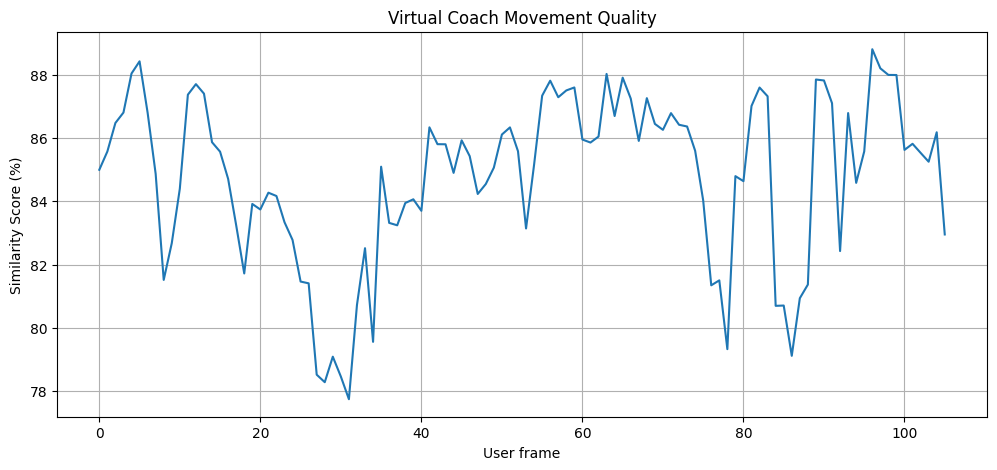

In [55]:
# Plot score curve

# график показывает (где движение выполнялось лучше или хуже)

plt.figure(
    figsize=(12,5)
)


plt.plot(
    df["user_frame"],
    df["score"]
)



plt.xlabel(
    "User frame"
)



plt.ylabel(
    "Similarity Score (%)"
)



plt.title(
    "Virtual Coach Movement Quality"
)



plt.grid()


plt.show()

In [56]:
# Save plot
# путь (results/plots/score_curve.png)

PLOT_PATH = (
    f"{PLOTS_DIR}/"
    "score_curve.png"
)



plt.figure(
    figsize=(12,5)
)


plt.plot(
    df["user_frame"],
    df["score"]
)



plt.xlabel(
    "Frame"
)


plt.ylabel(
    "Score %"
)


plt.title(
    "Virtual Coach Score Curve"
)


plt.grid()



plt.savefig(
    PLOT_PATH,
    bbox_inches="tight"
)



plt.close()



print(
    PLOT_PATH
)

/content/drive/MyDrive/Virtual_Coach/results/plots/score_curve.png


In [57]:
# Automatic Feedback

if average_score >= 90:


    feedback = (
        "Excellent performance. "
        "Movement is very close to reference."
    )



elif average_score >= 75:


    feedback = (
        "Good performance. "
        "Minor corrections are recommended."
    )



elif average_score >= 50:


    feedback = (
        "Needs improvement. "
        "Technique correction is required."
    )



else:


    feedback = (
        "Low similarity. "
        "Repeat the exercise with attention "
        "to body position."
    )



print(feedback)

Good performance. Minor corrections are recommended.


In [58]:
# Final Report Object
# для презентации удобно собрать один объект.

final_report = {

    "project":
    "Virtual Coach AI",


    "frames_compared":
    len(df),


    "average_score":
    round(average_score,2),


    "minimum_score":
    round(minimum_score,2),


    "maximum_score":
    round(maximum_score,2),


    "feedback":
    feedback

}



final_report

{'project': 'Virtual Coach AI',
 'frames_compared': 106,
 'average_score': np.float32(84.76),
 'minimum_score': 77.74,
 'maximum_score': 88.81,
 'feedback': 'Good performance. Minor corrections are recommended.'}

In [59]:
# Create Final Results Structure
import os


# Главная папка результатов
RESULTS_DIR = f"{PROJECT_DIR}/results"


# Подпапки результатов
RESULT_FOLDERS = {

    "video": f"{RESULTS_DIR}/video",

    "csv": f"{RESULTS_DIR}/csv",

    "plots": f"{RESULTS_DIR}/plots"

}



# Создание папок

for name, path in RESULT_FOLDERS.items():

    os.makedirs(
        path,
        exist_ok=True
    )

    print(
        f"{name}: {path}"
    )



print("\nResults structure ready")

video: /content/drive/MyDrive/Virtual_Coach/results/video
csv: /content/drive/MyDrive/Virtual_Coach/results/csv
plots: /content/drive/MyDrive/Virtual_Coach/results/plots

Results structure ready


In [60]:
# Проверка
import os


for root, dirs, files in os.walk(RESULTS_DIR):

    level = root.replace(
        RESULTS_DIR,
        ""
    ).count(os.sep)

    indent = " " * 4 * level

    print(
        indent + os.path.basename(root) + "/"
    )

    for file in files:

        print(
            indent + "    " + file
        )

results/
    video/
        Virtual_Coach_Final_fixed.mp4
        Virtual_Coach_Final.mp4
    csv/
        dtw_scores.csv
        final_report.csv
    plots/
        score_curve.png
    videos/
    reports/


In [61]:
from pathlib import Path


RESULTS = Path(PROJECT_DIR) / "results"


VIDEO_DIR = RESULTS / "video"

CSV_DIR = RESULTS / "csv"

PLOTS_DIR = RESULTS / "plots"



for folder in [
    VIDEO_DIR,
    CSV_DIR,
    PLOTS_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


print("Final output folders created")

Final output folders created


Финальное заключение Sprint IV

# Final Conclusion — Virtual Coach Sprint IV

В рамках Sprint IV была реализована полноценная система AI Virtual Coach.

Система выполняет полный цикл анализа движения:

1. Загружает видео тренера и пользователя.

2. Извлекает кадры из видео.

3. Использует Keypoint R-CNN для определения положения тела.

4. Представляет человека как набор 17 ключевых точек COCO.

5. Выполняет нормализацию и геометрическое выравнивание поз.

6. Автоматически находит соответствующий фрагмент движения.

7. Использует Dynamic Time Warping для синхронизации последовательностей.

8. Рассчитывает сходство движений через:
   - cosine similarity
   - weighted distance

9. Формирует:
   - итоговый score
   - CSV отчёт
   - график качества движения
   - сравнительное видео


Полученный результат демонстрирует возможность создания
AI-системы виртуального тренера, которая может оценивать
технику выполнения упражнений по видео пользователя.

# Подготовка проекта для GitHub

На этом этапе создаются дополнительные файлы,
необходимые для публикации проекта в репозитории GitHub:

- requirements.txt — список используемых библиотек и зависимостей;
- scripts/main.py — основной файл запуска проекта;
- images/pipeline.png — схема рабочего процесса Virtual Coach AI;
- images/architecture.png — архитектура системы;
- проверка итоговой структуры проекта.

In [62]:
# Создание всей структуры проекта
import os

PROJECT_DIR = "/content/drive/MyDrive/Virtual_Coach"

folders = [

    "src",

    "scripts",

    "notebooks",

    "images",

    "data",

    "data/videos",

    "data/videos/coach",

    "data/videos/user",

    "results",

    "results/csv",

    "results/video",

    "results/plots"

]

for folder in folders:

    os.makedirs(
        os.path.join(PROJECT_DIR, folder),
        exist_ok=True
    )

print("Project folders successfully created.")

Project folders successfully created.


In [76]:
# Проверка созданной структуры через tree

#PROJECT_DIR = "/content/drive/MyDrive/Virtual_Coach"

#!tree -L 3 "{PROJECT_DIR}"

In [67]:
# Проверка из Colab ноутбука
import os

NOTEBOOK_PATH = (
    "/content/drive/MyDrive/"
    "Virtual_Coach/notebooks/"
    "Copy of Sprint_4_Virtual_Coach_Final.ipynb"
)

if os.path.exists(NOTEBOOK_PATH):

    print("Notebook found")

else:

    print("Notebook not found")

Notebook found


In [68]:
# Создание requirements.txt
%%writefile /content/drive/MyDrive/Virtual_Coach/requirements.txt

torch
torchvision
opencv-python
numpy
pandas
matplotlib
scipy
dtaidistance
fastdtw
tqdm
Pillow
jupyter
notebook

Overwriting /content/drive/MyDrive/Virtual_Coach/requirements.txt


In [69]:
# Создание main.py
import os

os.makedirs(
    "/content/drive/MyDrive/Virtual_Coach/scripts",
    exist_ok=True
)

print("scripts folder ready")

scripts folder ready


In [70]:
# Создать scripts/main.py

%%writefile /content/drive/MyDrive/Virtual_Coach/scripts/main.py

"""
Virtual Coach AI

Entry point of the project.

Pipeline

1. Load videos
2. Pose estimation
3. Pose normalization
4. DTW synchronization
5. Similarity calculation
6. Feedback generation
"""

from src.pose_model import predict_pose
from src.video_utils import extract_frames


def main():

    print("Virtual Coach AI started")

    print("Loading videos...")

    print("Pose estimation...")

    print("DTW synchronization...")

    print("Similarity calculation...")

    print("Feedback generation...")

    print("Pipeline completed successfully.")


if __name__ == "__main__":

    main()

Overwriting /content/drive/MyDrive/Virtual_Coach/scripts/main.py


In [71]:
# Создание изображений (images)
import os

os.makedirs(
    "/content/drive/MyDrive/Virtual_Coach/images",
    exist_ok=True
)

print("images folder ready")

images folder ready


In [72]:
# Создать pipeline.png

from PIL import Image, ImageDraw

path = (
    "/content/drive/MyDrive/Virtual_Coach/"
    "images/pipeline.png"
)


img = Image.new(
    "RGB",
    (1200,700),
    "white"
)


draw = ImageDraw.Draw(img)


pipeline = """
Virtual Coach AI Pipeline


Video Input

↓

Frame Extraction

↓

Keypoint R-CNN

↓

17 Body Keypoints

↓

Pose Normalization

↓

DTW Synchronization

↓

Similarity Metrics

↓

Score + Feedback
"""


draw.text(
    (100,50),
    pipeline,
    fill="black"
)


img.save(path)


print(
    "Saved:",
    path
)

Saved: /content/drive/MyDrive/Virtual_Coach/images/pipeline.png


In [73]:
# Создать architecture.png

from PIL import Image, ImageDraw

path = (
    "/content/drive/MyDrive/Virtual_Coach/"
    "images/architecture.png"
)


img = Image.new(
    "RGB",
    (1400,800),
    "white"
)


draw = ImageDraw.Draw(img)


architecture = """

Virtual Coach AI Architecture


USER VIDEO

↓

Video Processing

↓

Keypoint R-CNN Model

↓

Pose Extraction

↓

Normalization

↓

DTW Alignment

↓

Similarity Metrics

↓

Final Score

↓

Feedback Report

"""


draw.text(
    (100,50),
    architecture,
    fill="black"
)


img.save(path)


print(
    "Saved:",
    path
)

Saved: /content/drive/MyDrive/Virtual_Coach/images/architecture.png


In [74]:
# Финальная проверка структуры проекта
import os


PROJECT_DIR = "/content/drive/MyDrive/Virtual_Coach"


print("=" * 70)
print("Virtual Coach AI - Final Project Structure")
print("=" * 70)


for root, dirs, files in os.walk(PROJECT_DIR):

    level = root.replace(
        PROJECT_DIR,
        ""
    ).count(os.sep)


    if level <= 2:

        indent = "    " * level

        folder = os.path.basename(root)

        if folder == "":
            folder = "Virtual_Coach"


        print(
            f"{indent} {folder}/"
        )


        for file in sorted(files):

            print(
                f"{indent}     {file}"
            )


print("=" * 70)
print(" Project structure verified")
print(" Ready for GitHub repository")
print("=" * 70)

Virtual Coach AI - Final Project Structure
 Virtual_Coach/
     .gitignore
     README.md
     requirements.txt
     results/
         video/
             Virtual_Coach_Final.mp4
             Virtual_Coach_Final_fixed.mp4
         csv/
             dtw_scores.csv
             final_report.csv
         plots/
             score_curve.png
         videos/
         reports/
     src/
         __init__.py
         pose_model.py
         pose_utils.py
         video_utils.py
         visualization.py
         virtual_coach/
             __init__.py
             metrics.py
             pose_model.py
             pose_utils.py
             video_utils.py
             visualization.py
         __pycache__/
             __init__.cpython-312.pyc
             pose_model.cpython-312.pyc
             pose_utils.cpython-312.pyc
             video_utils.cpython-312.pyc
             visualization.cpython-312.pyc
     data/
         videos/
     scripts/
         main.py
     images/
         architect

In [77]:
# Show Virtual Coach project structure
# Проверка созданной структуры через tree

PROJECT_DIR = "/content/drive/MyDrive/Virtual_Coach"

!tree -L 3 "{PROJECT_DIR}"

/content/drive/MyDrive/Virtual_Coach
├── data
│   └── videos
│       ├── coach
│       └── user
├── docs
├── examples
│   └── Sprint_4_Virtual_Coach_Final.ipynb
├── images
│   ├── architecture.png
│   ├── demo_frame.png
│   └── pipeline.png
├── notebooks
│   └── Copy of Sprint_4_Virtual_Coach_Final.ipynb
├── README.md
├── requirements.txt
├── results
│   ├── csv
│   │   ├── dtw_scores.csv
│   │   └── final_report.csv
│   ├── plots
│   │   └── score_curve.png
│   ├── reports
│   ├── video
│   │   ├── Virtual_Coach_Final_fixed.mp4
│   │   └── Virtual_Coach_Final.mp4
│   └── videos
├── scripts
│   └── main.py
└── src
    ├── __init__.py
    ├── pose_model.py
    ├── pose_utils.py
    ├── __pycache__
    │   ├── __init__.cpython-312.pyc
    │   ├── pose_model.cpython-312.pyc
    │   ├── pose_utils.cpython-312.pyc
    │   ├── video_utils.cpython-312.pyc
    │   └── visualization.cpython-312.pyc
    ├── video_utils.py
    ├── virtual_coach
    │   ├── __init__.py
    │   ├── metrics.py
    │